# Prediccion de puntajes de examenes escolares

### Setup del entorno

In [1]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Exploracion de datos

In [2]:
# Carga de datos
df = pd.read_csv('data/test_scores.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school           2133 non-null   object 
 1   school_setting   2133 non-null   object 
 2   school_type      2133 non-null   object 
 3   classroom        2133 non-null   object 
 4   teaching_method  2133 non-null   object 
 5   n_student        2133 non-null   float64
 6   student_id       2133 non-null   object 
 7   gender           2133 non-null   object 
 8   lunch            2133 non-null   object 
 9   pretest          2133 non-null   float64
 10  posttest         2133 non-null   float64
dtypes: float64(3), object(8)
memory usage: 183.4+ KB


Podemos ver que existen 2133 registos y 11 columnas en nuestro dataset. De las columnas tenemos 8 columnas que parecen ser categoricas y 3 numericas (n_student, pretest, posttest). A simple vista parece que no hay valores faltantes en el dataset, pero esto no quiere decir que no existan (ya que pueden venir textualmente como "N.A.").

In [3]:
# Vista de las primeras 10 filas
df.head(10)

,school,school_setting,school_type,classroom,teaching_method,n_student,student_id,gender,lunch,pretest,posttest
0,ANKYI,Urban,Non-public,6OL,Standard,20.0,2FHT3,Female,Does not qualify,62.0,72.0
1,ANKYI,Urban,Non-public,6OL,Standard,20.0,3JIVH,Female,Does not qualify,66.0,79.0
2,ANKYI,Urban,Non-public,6OL,Standard,20.0,3XOWE,Male,Does not qualify,64.0,76.0
3,ANKYI,Urban,Non-public,6OL,Standard,20.0,556O0,Female,Does not qualify,61.0,77.0
4,ANKYI,Urban,Non-public,6OL,Standard,20.0,74LOE,Male,Does not qualify,64.0,76.0
5,ANKYI,Urban,Non-public,6OL,Standard,20.0,7YZO8,Female,Does not qualify,66.0,74.0
6,ANKYI,Urban,Non-public,6OL,Standard,20.0,9KMZD,Male,Does not qualify,63.0,75.0
7,ANKYI,Urban,Non-public,6OL,Standard,20.0,9USQK,Female,Does not qualify,63.0,72.0
8,ANKYI,Urban,Non-public,6OL,Standard,20.0,CS5QP,Male,Does not qualify,64.0,77.0
9,ANKYI,Urban,Non-public,6OL,Standard,20.0,D6HT8,Female,Does not qualify,61.0,72.0


Viendo el dataset y consultando la informacion que viene en la pagina de kaggle, tenemos la siguiente informacion sobre las columnas:

| School | school_setting | school_type | classroom | teaching_method | n_student | gender | lunch | pretest | posttest |
|--------|----------------|-------------|-----------|-----------------|-----------|--------|-------|---------|----------|
| Nombre de la escuela del alumno | Ubicacion de la escuela | Tipo de escuela | Tipo de salon | Metodo de enseñanza utilizado | Numero de estudiantes en el aula | Genero del alumno | Si el alumno recibe almuerzo subsidiado | Puntaje del pretest del alumno | Puntaje del postest del alumno |

In [4]:
# Análisis de valores en columnas
columns = df.columns.tolist()
unique_values = []

for column in columns:
    print(f"Variable: {column}")
    print(f"Numero de valores unicos: {df[column].nunique()}")
    print(f"Valores unicos: {df[column].unique()}")
    print("\n")

Variable: school
Numero de valores unicos: 23
Valores unicos: ['ANKYI' 'CCAAW' 'CIMBB' 'CUQAM' 'DNQDD' 'FBUMG' 'GJJHK' 'GOKXL' 'GOOBU'
 'IDGFP' 'KFZMY' 'KZKKE' 'LAYPA' 'OJOBU' 'QOQTS' 'UAGPU' 'UKPGS' 'UUUQX'
 'VHDHF' 'VKWQH' 'VVTVA' 'ZMNYA' 'ZOWMK']


Variable: school_setting
Numero de valores unicos: 3
Valores unicos: ['Urban' 'Suburban' 'Rural']


Variable: school_type
Numero de valores unicos: 2
Valores unicos: ['Non-public' 'Public']


Variable: classroom
Numero de valores unicos: 97
Valores unicos: ['6OL' 'ZNS' '2B1' 'EPS' 'IQN' 'PGK' 'UHU' 'UWK' 'A33' 'EID' 'HUJ' 'PC6'
 '1Q1' 'BFY' 'OMI' 'X6Z' '2AP' 'PW5' 'ROP' 'ST7' 'XXJ' '197' '5LQ' 'JGD'
 'HCB' 'NOR' 'X78' 'YUC' 'ZDT' 'ENO' 'TSA' 'VA6' '18K' 'CXC' 'HKF' 'PBA'
 'U6J' 'W8A' '05H' '98D' 'G2L' 'P2A' 'XZM' '1VD' '21Q' '2BR' '3D0' '5JK'
 'O6A' 'QTU' 'AJ1' 'J8J' 'RA5' '5SZ' '6U9' 'FS3' 'XJ8' '0N7' '3XJ' 'RK7'
 'SUR' 'X2O' 'XZ4' '1SZ' '62L' 'NWZ' 'S98' '08N' '9AW' 'IPU' 'KXB' 'PGH'
 'XXE' '6C1' 'AE1' 'H7S' 'P8I' 'SSP' 'CD8' 'J6X' 'KR1

In [5]:
# Análisis estadístico de las variables numéricas
df[['n_student', 'pretest', 'posttest']].describe()

,n_student,pretest,posttest
count,2133.000000,2133.000000,2133.000000
mean,22.796531,54.955931,67.102203
std,4.228893,13.563101,13.986789
min,14.000000,22.000000,32.000000
25%,20.000000,44.000000,56.000000
50%,22.000000,56.000000,68.000000
75%,27.000000,65.000000,77.000000
max,31.000000,93.000000,100.000000


Des pues de ver mas detenidamente los valores de las columnas categoricas, podemos encontrar lo siguiente:
- Columnas como "student_id" y "classroom" no son utiles para nuestro analisis por alumno, ya que cuentan con muchos valores unicos y esto puede afectar el rendimiento del modelo.
- La variable de "n_student", aunque parece numerica, en realidad es categorica, ya que representa el numero de estudiantes en el aula y no una cantidad continua. Ademas, no aporta informacion relevante para predecir el puntaje del examen.
- No hay presencia de valores nulos como "N.A.", "No Aplica", etc. en las columnas categoricas. Por ende, toda la informacion es valida.
- Variables como "school", "school_setting", "school_type", "teaching_method", "gender" y "lunch" son variables demograficas que pueden decirnos mucho sobre el contexto del alumno y su rendimiento academico, por lo que son las que utilizaremos para nuestro analisis.
- La variable "pretest" nos da una idea del conocimiento previo del alumno, por lo que si le sumamos a esta todo el conjunto de variables demograficas, podemos tener un buen modelo para predecir el puntaje del "posttest".

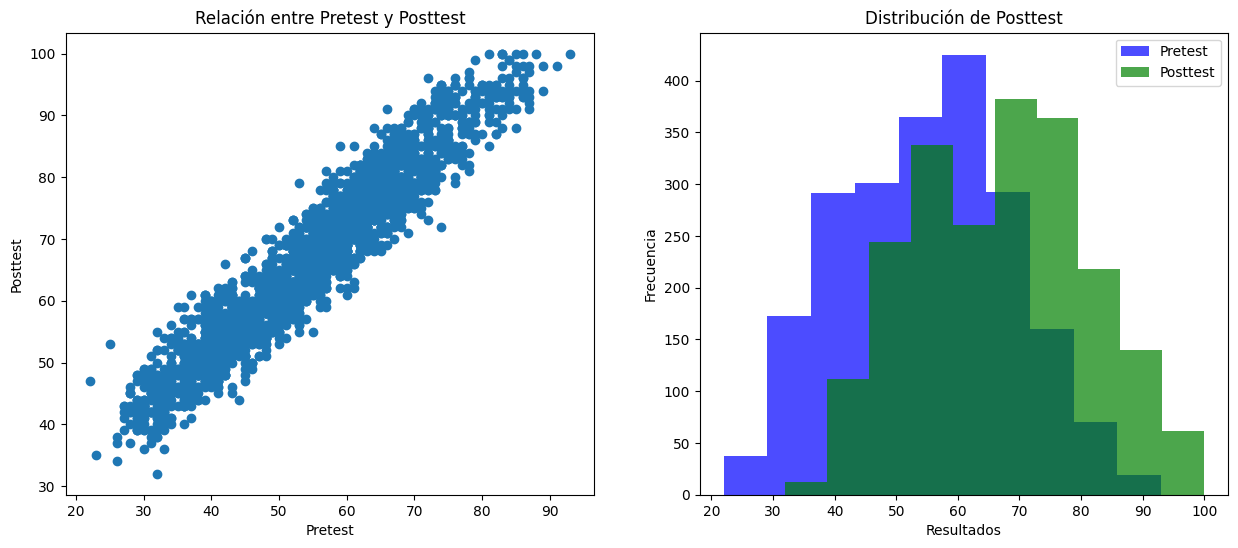

In [6]:
# relacion de pretest y posttest
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
plt.scatter(df['pretest'], df['posttest'])
plt.title('Relación entre Pretest y Posttest')
plt.xlabel('Pretest')
plt.ylabel('Posttest')

plt.subplot(1, 2, 2)
plt.hist(df['pretest'], color='blue', alpha=0.7)
plt.title('Distribución de Pretest')
plt.hist(df['posttest'], color='green', alpha=0.7)
plt.title('Distribución de Posttest')

plt.xlabel('Resultados')
plt.ylabel('Frecuencia')
plt.legend(['Pretest', 'Posttest'])

plt.show()

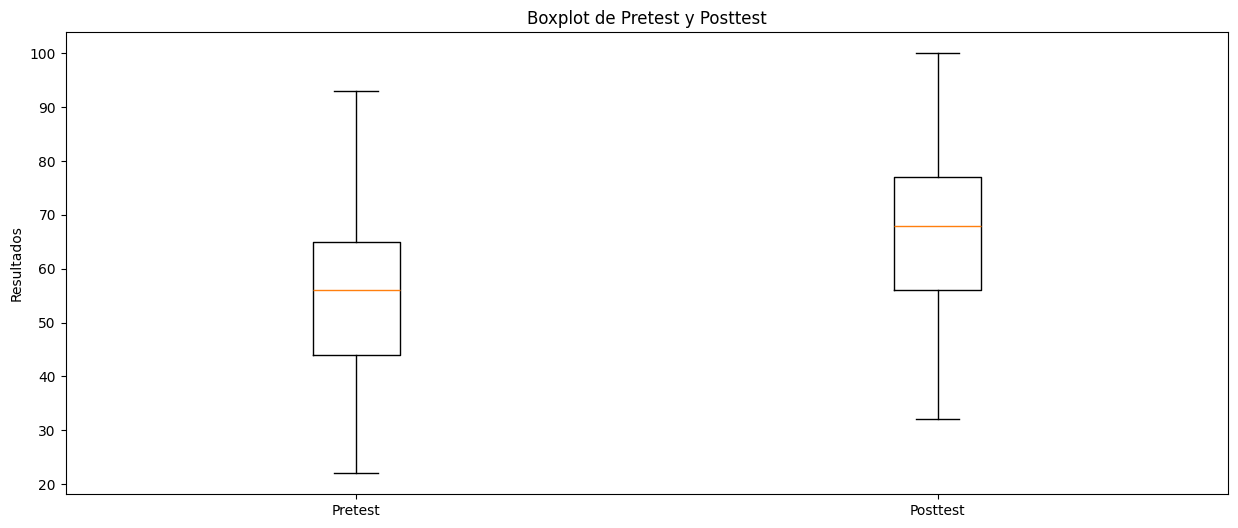

In [7]:
plt.figure(figsize=(15,6))

plt.boxplot([df['pretest'], df['posttest']], tick_labels=['Pretest', 'Posttest'])
plt.title('Boxplot de Pretest y Posttest')
plt.ylabel('Resultados')

plt.show()

Se pude observar que existe una relacion positiva entre los puntajes de pretest y posttest, lo que indica que los estudiantes que obtienen mejores resultados en el pretest tienden a obtener mejores resultados en el posttest. Adicionalmente, se observa que la distribucion de los puntajes, tanto en pretest como en posttest, es aproximadamente normal, y en la graficas de barras no se observan valores atipicos que puedan afectar el análisis.

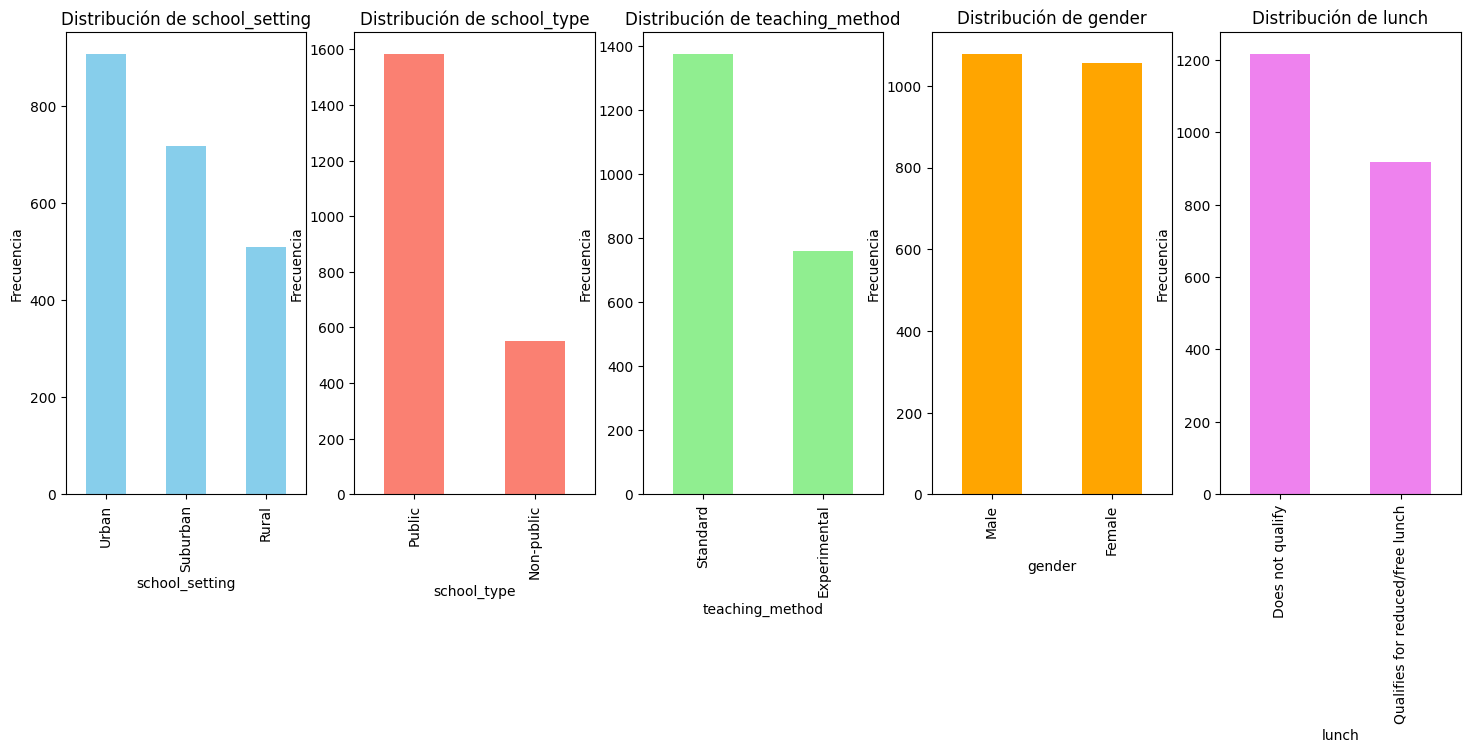

In [8]:
# Analisis de variables demograficas
demographic_vars = ['school_setting', 'school_type', 'teaching_method', 'gender', 'lunch']
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'violet']

plt.figure(figsize=(18,6))
for i, var in enumerate(demographic_vars):
    plt.subplot(1, 5, i+1)
    df[var].value_counts().plot(kind='bar', color=colors[i])
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
plt.show()

### Preparacion de datos

In [9]:
# Selección de características y variable objetivo
X = df[['school', 'school_setting', 'school_type', 'teaching_method', 'gender', 'lunch', 'pretest']]
y = df['posttest']

# Codificación de variables categóricas usando la funcion get_dummies de pandas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=['school', 'school_setting', 'school_type', 'teaching_method', 'gender', 'lunch'])

In [10]:
# Split de nuestro dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3)

print("Valores de train:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print("Valores de test:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Valores de train:
X_train shape: (1493, 35)
y_train shape: (1493,)
Valores de test:
X_test shape: (640, 35)
y_test shape: (640,)


### Construccion del modelo de regresión lineal multi-variable

In [11]:
# Entrenamiento del modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Metricas del modelo
y_train_pred = model.predict(X_train)

SSD = np.sum((y_train-y_train_pred)**2)
RSE = np.sqrt(SSD/(len(X_train)-1))
y_mean = np.mean(y_train)
RSE_rate = RSE/y_mean


print("Metricas de Train:")
y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("R2 = ", r2_train)
print("MSE = ", mse_train)
print("RMSE = ", np.sqrt(mse_train))

Metricas de Train:
R2 =  0.9494429519286683
MSE =  9.676533661343038
RMSE =  3.110712725621419


### Validacion del modelo

In [12]:
y_test_pred = model.predict(X_test)

print("Metricas de Test:")
print("Numero de variables: ", X_test.shape[1])
y_test_pred = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("R2 = ", r2_test)
print("MSE = ", mse_test)
print("RMSE = ", np.sqrt(mse_test))

Metricas de Test:
Numero de variables:  35
R2 =  0.9508479438480893
MSE =  10.06747342120487
RMSE =  3.1729282092737097


In [13]:
# Revision de coeficientes del modelo (absolutos)

coefficients = pd.DataFrame({'Feature': X_encoded.columns, 'Coefficient': np.abs(model.coef_)})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

                                   Feature  Coefficient
17                            school_UKPGS     3.280684
29            teaching_method_Experimental     3.120937
30                teaching_method_Standard     3.120937
11                            school_KFZMY     2.852817
10                            school_IDGFP     2.675742
21                            school_VVTVA     1.997811
3                             school_CIMBB     1.917788
12                            school_KZKKE     1.797932
9                             school_GOOBU     1.581485
23                            school_ZOWMK     1.390141
13                            school_LAYPA     1.192123
14                            school_OJOBU     1.145390
1                             school_ANKYI     1.094733
25                 school_setting_Suburban     1.063201
19                            school_VHDHF     1.042296
4                             school_CUQAM     1.025000
0                                  pretest     0

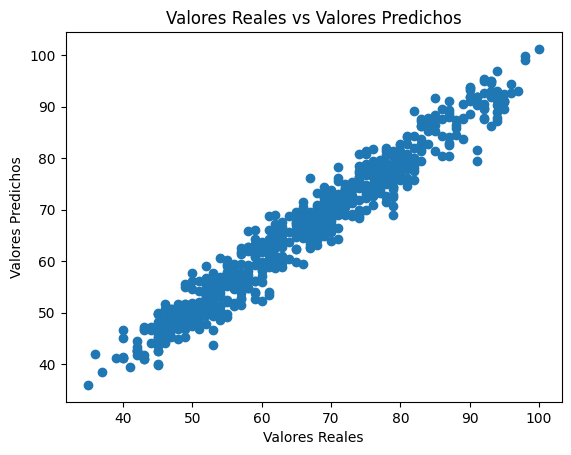

In [14]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Valores Reales vs Valores Predichos")
plt.show()

# Comparacion de modelos con diferentes variables independientes

### Modelo sin variables demograficas

In [15]:
x = df[['pretest']]
y = df['posttest']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

modelo_simple = LinearRegression()

modelo_simple.fit(x_train, y_train)

y_test_pred_simple = modelo_simple.predict(x_test)

print("Metricas de Test:")
print("Numero de variables: ", x_train.shape[1])
y_test_pred = modelo_simple.predict(x_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("R2 = ", r2_test)
print("MSE = ", mse_test)
print("RMSE = ", np.sqrt(mse_test))

Metricas de Test:
Numero de variables:  1
R2 =  0.8969230101366844
MSE =  18.574775305085403
RMSE =  4.309846320355913


### Modelo sin pretest

In [16]:
x = df[['school', 'school_setting', 'school_type', 'teaching_method', 'gender', 'lunch']]
x = pd.get_dummies(x, columns=['school', 'school_setting', 'school_type', 'teaching_method', 'gender', 'lunch'])
y = df['posttest']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

modelo_demografico = LinearRegression()

modelo_demografico.fit(x_train, y_train)

y_test_pred_demografico = modelo_demografico.predict(x_test)

print("Metricas de Test:")
print("Numero de variables: ", x_train.shape[1])
y_test_pred = modelo_demografico.predict(x_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("R2 = ", r2_test)
print("MSE = ", mse_test)
print("RMSE = ", np.sqrt(mse_test))

Metricas de Test:
Numero de variables:  34
R2 =  0.8291730703029646
MSE =  34.045556436800915
RMSE =  5.834857019396527


### Modelo sin escuela para disminuir la cantidad de variables

In [17]:
x = df[['school_setting', 'school_type', 'teaching_method', 'gender', 'lunch', 'pretest']]
x = pd.get_dummies(x, columns=['school_setting', 'school_type', 'teaching_method', 'gender', 'lunch'])
y = df['posttest']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

modelo_demografico = LinearRegression()

modelo_demografico.fit(x_train, y_train)

y_test_pred_demografico = modelo_demografico.predict(x_test)

print("Metricas de Test:")
print("Numero de variables: ", x_train.shape[1])
y_test_pred = modelo_demografico.predict(x_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("R2 = ", r2_test)
print("MSE = ", mse_test)
print("RMSE = ", np.sqrt(mse_test))

Metricas de Test:
Numero de variables:  12
R2 =  0.9514864048665601
MSE =  9.57536894440039
RMSE =  3.094409304600862
